In [1]:
import numpy as np
import pandas as pd
import risk_kit as rk
%load_ext autoreload
%autoreload 2

In [2]:
rates, zc_prices = rk.cir(10, 500, b = .03, r_0 = .03)
price_10 = rk.bond_price(10, 100, .05, 12, rates)
price_30 = rk.bond_price(30, 100, .05, 12, rates)
rets_30 = rk.bond_total_return(price_30, 100, .05, 12)
rets_10 = rk.bond_total_return(price_10, 100, .05, 12)


In [3]:
rets_bonds = rk.bt_mix(rets_10, rets_30, allocator = rk.fixedmix_allocator, w1=.6)
mean_rets_bonds = rets_bonds.mean(axis = 'columns')
rk.summary_stats(pd.DataFrame(mean_rets_bonds))

,Annualized Return,Annualized Vol,Skewness,Kurtosis,Cornish-Fisher VaR (5%),Historic CVaR (5%),Sharpe Ratio,Max Drawdown
0,0.035838,0.003486,-0.065551,3.043231,-0.001273,-0.000705,1.629883,0.0


In [6]:
price_eq = rk.gbm(n_years = 10, n_scenarios = 500, mu = .07, sigma = .15)
rets_eq = price_eq.pct_change().dropna()
rets_zc = zc_prices.pct_change().dropna()

In [9]:
rets_7030b = rk.bt_mix(rets_eq, rets_bonds, allocator = rk.fixedmix_allocator, w1 = 0.7)
rets_7030b_mean = rets_7030b.mean(axis = 1)
rk.summary_stats(pd.DataFrame(rets_7030b_mean))

,Annualized Return,Annualized Vol,Skewness,Kurtosis,Cornish-Fisher VaR (5%),Historic CVaR (5%),Sharpe Ratio,Max Drawdown
0,0.055908,0.004912,-0.384727,3.193032,-0.002077,-0.001149,5.133091,0.0


In [10]:
summaries = rk.summary_stats(rets_7030b)
summaries.head()

,Annualized Return,Annualized Vol,Skewness,Kurtosis,Cornish-Fisher VaR (5%),Historic CVaR (5%),Sharpe Ratio,Max Drawdown
0,0.062746,0.102202,0.211100,2.830413,0.041127,0.048151,0.311725,-0.183054
1,0.146032,0.107223,0.374866,3.797062,0.034948,0.047771,1.053218,-0.141306
2,0.008306,0.117765,-0.214360,3.168020,0.056338,0.073251,-0.179430,-0.329958
3,0.081708,0.111906,-0.249542,3.436162,0.047792,0.060413,0.449594,-0.159398
4,0.046178,0.096392,0.306127,2.823827,0.039068,0.043269,0.163232,-0.247379


In [11]:
summaries.mean()

Annualized Return          0.050411
Annualized Vol             0.107532
Skewness                   0.025322
Kurtosis                   2.929061
Cornish-Fisher VaR (5%)    0.046085
Historic CVaR (5%)         0.057814
Sharpe Ratio               0.185353
Max Drawdown              -0.211483
dtype: float64

In [13]:
pd.concat([
    rk.terminal_stats(rets_bonds, name = 'FI'), # fixed income
    rk.terminal_stats(rets_eq, name = 'Eq'),    # equity
    rk.terminal_stats(rets_7030b, name = '70/30')
], axis = 1)

,FI,Eq,70/30
mean,1.383723,1.862583,1.714872
std,0.114672,0.947171,0.581892
p_breach,NaN,0.058000,0.014000
e_short,NaN,0.124909,0.106932
p_reach,NaN,NaN,NaN
e_surplus,NaN,NaN,NaN


C:\Users\Yifei\AppData\Local\Temp\ipykernel_10288\2351924405.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(rk.terminal_values(rets_eq), color="red", label="100% Equities")
C:\Users\Yifei\AppData\Local\Temp\ipykernel_10288\2351924405.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(rk.te

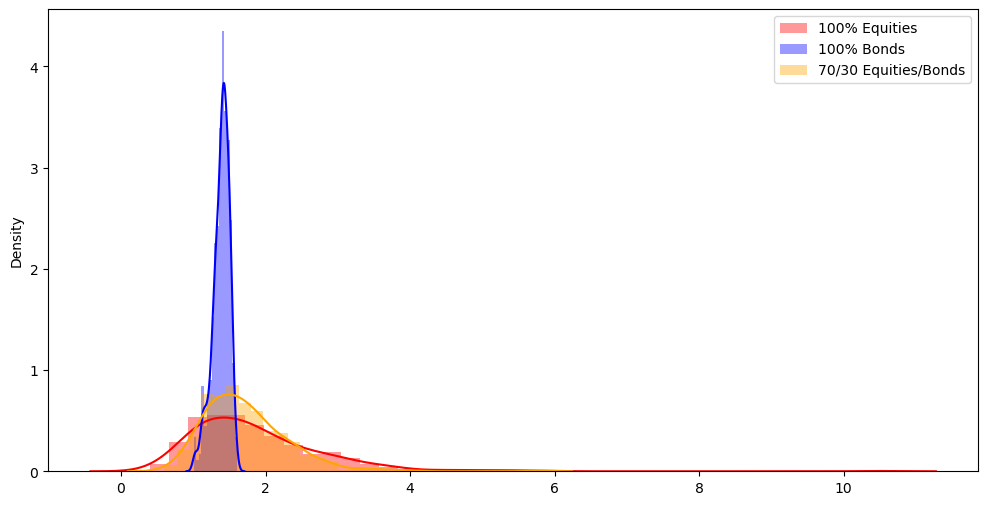

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
sns.distplot(rk.terminal_values(rets_eq), color="red", label="100% Equities")
sns.distplot(rk.terminal_values(rets_bonds), color="blue", label="100% Bonds")
sns.distplot(rk.terminal_values(rets_7030b), color="orange", label="70/30 Equities/Bonds")
plt.legend();

## Glide Paths for Allocation

In [25]:
def glidepath_allocator(r1, r2, start_glide = 1, end_glide = 0):
    """
    Simulates a Target-Date-Fund style gradual move from r1 to r2
    """
    n_points = r1.shape[0]
    n_col = r1.shape[1]
    path = pd.Series(data = np.linspace(start_glide, end_glide, num = n_points))
    paths = pd.concat([path] * n_col, axis = 1)
    path.index = r1.index
    path.columns = r1.columns
    return paths

In [26]:
rets_g8020 = rk.bt_mix(rets_eq, rets_bonds, allocator = rk.glidepath_allocator, start_glide = .8, end_glide = .2)

In [28]:
pd.concat([
    rk.terminal_stats(rets_bonds, name = 'FI'), # fixed income
    rk.terminal_stats(rets_eq, name = 'Eq'),    # equity
    rk.terminal_stats(rets_7030b, name = '70/30'),
    rk.terminal_stats(rets_g8020, name = 'glide 80 to 20')
], axis = 1)

,FI,Eq,70/30,glide 80 to 20
mean,1.383723,1.862583,1.714872,1.610807
std,0.114672,0.947171,0.581892,0.412883
p_breach,NaN,0.058000,0.014000,0.004000
e_short,NaN,0.124909,0.106932,0.010486
p_reach,NaN,NaN,NaN,NaN
e_surplus,NaN,NaN,NaN,NaN
